## 0. Cài đặt và Import thư viện

In [8]:
# Cài đặt thư viện
import subprocess
import sys
from pathlib import Path

# Thêm đường dẫn gốc của dự án vào sys.path để import các module tùy chỉnh
BASE_DIR = Path(r"C:\Users\ASUS-PRO\Desktop\Traffic_Law_Chatbot")
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

from rag.chunking import get_text_chunks

# Cài đặt thư viện bằng subprocess để tránh lỗi đường dẫn Python có khoảng trắng
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "underthesea",
        "wordcloud",
        "matplotlib",
        "langchain",
        "langchain-text-splitters",
    ]
)

0

In [2]:
# Import thư viện
import json
import re
import string
import unicodedata
from collections import Counter
from datetime import datetime

import matplotlib.pyplot as plt
from wordcloud import WordCloud


In [3]:
# Đọc dữ liệu từ các file JSON đã crawl
BASE_DIR = Path(r"C:\Users\ASUS-PRO\Desktop\Traffic_Law_Chatbot")
RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

# Đọc Luật 35/2024
with open(RAW_DIR / "luat_duong_bo_35-2024.json", encoding="utf-8") as f:
    luat_35 = json.load(f)

# Đọc Nghị định 168/2024
with open(RAW_DIR / "nd168_xu_phat_2024.json", encoding="utf-8") as f:
    nd168 = json.load(f)

# Gộp các văn bản đã đọc
documents = [
    {"name": "Luật 35/2024/QH15", "text": luat_35["full_text"]},
    {"name": "Nghị định 168/2024/NĐ-CP", "text": nd168["full_text"]},
]

# Gộp toàn bộ văn bản
full_text_corpus = "\n\n".join(doc["text"] for doc in documents)

print(f"✓ Đã đọc {len(documents)} văn bản pháp luật")
print(f"✓ Tổng số ký tự trong kho văn bản: {len(full_text_corpus):,}")
# Xóa bỏ logic xử lý theo trang (all_pages)
# all_pages = []
# for page in luat_35.get("pages", []):
#     all_pages.append({"source": "Luật 35/2024", "page": page["page_number"], "text": page["content"]})
# for page in nd168.get("pages", []):
#     all_pages.append({"source": "NĐ 168/2024", "page": page["page_number"], "text": page["content"]})

# print(f"✓ Tổng số trang: {len(all_pages)}")
# for doc in documents:
#     print(f"  - {doc['name']}: {len(doc['text']):,} ký tự")


✓ Đã đọc 2 văn bản pháp luật
✓ Tổng số ký tự trong kho văn bản: 404,996


## Bước 1-6: Tiền xử lý văn bản (Text Preprocessing Pipeline)

Gộp các bước tiền xử lý vào một pipeline duy nhất để đảm bảo thứ tự thực hiện chính xác, đặc biệt là việc **chuẩn hóa các thực thể pháp lý (Điều, Khoản, Nghị định) TRƯỚC KHI tách từ**.

**Thứ tự pipeline:**
1.  **Chuẩn hóa thực thể pháp lý**: Nối "Điều 5" -> "dieu_5", "Nghị định 100" -> "nghidinh_100",...
2.  **Chuyển về chữ thường** (Lowercasing).
3.  **Chuẩn hóa viết tắt & Sửa lỗi chính tả**.
4.  **Xóa dấu câu, ký tự đặc biệt**.
5.  **Tách từ tiếng Việt** (Tokenization).
6.  **Xóa từ dừng** (Stopword Removal).

In [4]:
# Gộp các bước 1-6 vào một pipeline xử lý
print("=" * 50)
print("BƯỚC 1-6: CHẠY PIPELINE TIỀN XỬ LÝ VĂN BẢN")
print("=" * 50)

import re
import unicodedata
from underthesea import word_tokenize

# Danh sách từ dừng tiếng Việt (có thể mở rộng thêm)
VIETNAMESE_STOPWORDS = {
    "tôi", "tao", "mình", "ta", "chúng_tôi", "chúng_ta", "bạn", "anh", "chị", "nó", "họ", "hắn", "em",
    "của", "và", "là", "có", "được", "trong", "cho", "này", "theo", "với", "từ", "đến", "về", "tại", 
    "trên", "dưới", "ngoài", "giữa", "sau", "trước", "bởi", "qua", "bằng", "vào", "ra", "lên", "xuống",
    "các", "những", "một", "mọi", "mỗi", "tất_cả", "toàn_bộ", "đã", "đang", "sẽ", "vẫn", "còn", "cũng", 
    "rất", "lại", "nữa", "rồi", "thì", "mà", "nên", "hay", "hoặc", "nhưng", "nếu", "vì", "do", "để",
    "khi", "cùng", "như", "hơn", "nhất", "quá", "gì", "nào", "đâu", "sao", "bao_giờ", "ai", "không", 
    "chưa", "chẳng", "đừng", "đó", "đây", "kia", "ấy", "thế", "vậy", "ở", "bị", "phải", "cần", "hết", 
    "ngay", "liền", "rằng", "tuy", "dù", "mặc_dù", "tuy_nhiên", "thêm", "nào_đó", "chính", "chỉ", 
    "đều", "từng", "vừa", "mới", "suốt", "luôn", "luôn_luôn"
}

def preprocess_text(text):
    """
    Pipeline tiền xử lý văn bản luật giao thông hoàn chỉnh.
    """
    # --- BƯỚC 1: Chuẩn hóa thực thể pháp lý (thực hiện đầu tiên) ---
    # Nối "Điều 5", "khoản 1", "điểm a" thành token duy nhất
    # re.IGNORECASE để bắt cả "Điều" và "điều"
    text = re.sub(r'điều\s+(\d+)', r' dieu_\1 ', text, flags=re.IGNORECASE)
    text = re.sub(r'khoản\s+(\d+)', r' khoan_\1 ', text, flags=re.IGNORECASE)
    # regex để bắt các mục a), b), c) và chuyển thành diem_a, diem_b...
    text = re.sub(r'\b([a-zđ])\)', r' diem_\1 ', text, flags=re.IGNORECASE)
    
    # Chuẩn hóa tên văn bản luật
    text = re.sub(r'(nghị định|nđ)\s+(số\s+)?168(/2024/nđ-cp)?', ' nghidinh_168_2024 ', text, flags=re.IGNORECASE)
    text = re.sub(r'(luật|luat)\s+(số\s+)?35(/2024/qh15)?', ' luat_35_2024 ', text, flags=re.IGNORECASE)

    # --- BƯỚC 2: Chuyển về chữ thường ---
    text = text.lower()

    # --- BƯỚC 3: Chuẩn hóa viết tắt & Sửa lỗi chính tả ---
    abbreviations = {
        "nđ cp": "nghị định chính phủ", "tt": "thông tư", "qh": "quốc hội", "cp": "chính phủ",
        "bgtvt": "bộ giao thông vận tải", "gtvt": "giao thông vận tải", "gtđb": "giao thông đường bộ",
        "đbvn": "đường bộ việt nam", "atgt": "an toàn giao thông", "gplx": "giấy phép lái xe",
        "ptgt": "phương tiện giao thông", "ubnd": "ủy ban nhân dân", "tngt": "tai nạn giao thông",
        "csgt": "cảnh sát giao thông", "km h": "ki lô mét trên giờ", "km/h": "ki lô mét trên giờ",
    }
    for abbr, full in abbreviations.items():
        text = text.replace(abbr, full)
        
    corrections = {
        "nguời": "người", "nguoi": "người", "dưòng": "đường", "duong": "đường", "phuong tien": "phương tiện",
        "phuơng tiện": "phương tiện", "giao thong": "giao thông", "vi pham": "vi phạm", "xu phat": "xử phạt",
        "xu lý": "xử lý", "hanh chinh": "hành chính", "quy dinh": "quy định", "dieu khien": "điều khiển",
        "toc do": "tốc độ", "phuong": "phương", "đuờng": "đường", "dieu": "điều", "khoan": "khoản",
        "ngh ị": "nghị", "đ ịnh": "định", "ph ạt": "phạt", "nghidinh": "nghị định", "bien bao": "biển báo",
        "đăng ky": "đăng ký", "đăng kiêm": "đăng kiểm", "lai xe": "lái xe",
    }
    for wrong, correct in corrections.items():
        text = text.replace(wrong, correct)

    # --- BƯỚC 4: Xóa dấu câu, ký tự đặc biệt ---
    # Giữ lại ký tự chữ, số, khoảng trắng và dấu gạch dưới (cho các thực thể đã nối)
    text = re.sub(r'[^\w\s_]', ' ', text)
    
    # --- BƯỚC 5: Tách từ tiếng Việt ---
    # underthesea sẽ tôn trọng các token đã có dấu gạch dưới
    tokens = word_tokenize(text)
    text = ' '.join(tokens)
    
    # --- BƯỚC 6: Xóa từ dừng ---
    words = text.split()
    filtered_words = [word for word in words if word not in VIETNAMESE_STOPWORDS]
    text = " ".join(filtered_words)
    
    # --- Cuối cùng: Chuẩn hóa lại khoảng trắng ---
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Áp dụng pipeline cho toàn bộ kho văn bản
print("Bắt đầu áp dụng pipeline tiền xử lý cho toàn bộ kho văn bản...")
processed_corpus = preprocess_text(full_text_corpus)
print(f"\n✓ Hoàn tất tiền xử lý.")
print(f"   - Ký tự trước xử lý: {len(full_text_corpus):,}")
print(f"   - Ký tự sau xử lý: {len(processed_corpus):,}")


# Demo kết quả
print(f"\n📌 Demo kết quả trên một đoạn văn bản:")
print("\n🔹 TRƯỚC (original):")
print(full_text_corpus[2000:2500])
print("\n🔹 SAU (đã qua pipeline xử lý):")
print(processed_corpus[1500:2000])


BƯỚC 1-6: CHẠY PIPELINE TIỀN XỬ LÝ VĂN BẢN
Bắt đầu áp dụng pipeline tiền xử lý cho toàn bộ kho văn bản...

✓ Hoàn tất tiền xử lý.
   - Ký tự trước xử lý: 404,996
   - Ký tự sau xử lý: 334,113

📌 Demo kết quả trên một đoạn văn bản:

🔹 TRƯỚC (original):
p quản lý, sử dụng,
vận hành, khai thác công trình đường bộ hoặc tổ chức, cá nhân được giao quản lý,
sử dụng, vận hành, khai thác công trình đường bộ.
Điều 3. Nguyên tắc hoạt động đường bộ
1. Bảo đảm giao thông thông suốt, an toàn, kết nối đồng bộ, hiệu quả, thân
thiện với môi trường, phục vụ nhu cầu vận tải hàng hóa và đi lại thuận tiện của
người dân, góp phần phát triển kinh tế - xã hội, bảo đảm quốc phòng, an ninh và
bảo vệ môi trường, phòng, chống thiên tai, hội nhập quốc tế.
2. Phát triển đ

🔹 SAU (đã qua pipeline xử lý):
n tải giúp bộ trưởng bộ giao thông vận tải thực hiện chức năng quản lý nhà nước hoạt động đường bộ cơ quan chuyên môn thuộc ủy ban nhân dân cấp tỉnh cơ quan chuyên môn thuộc ủy ban nhân dân cấp huyện ủy ban nhân dân

## Bước 7: Chia văn bản thành các chunks (Chunk Splitting)

Sử dụng RecursiveCharacterTextSplitter từ rag/chunking.py

In [5]:
# --- 7.1. Chia văn bản thành các chunks ---
print("=" * 50)
print("BƯỚC 7: CHIA VĂN BẢN THÀNH CHUNKS (CHUNK SPLITTING)")
print("=" * 50)

# Sử dụng RecursiveCharacterTextSplitter từ rag/chunking.py
CHUNK_SIZE = 1000
CHUNK_OVERLAP = 150

print(f"Bắt đầu chia văn bản thành các chunks...")
print(f"Chunk size: {CHUNK_SIZE}, Chunk overlap: {CHUNK_OVERLAP}")

# Gọi hàm get_text_chunks
chunks = get_text_chunks(processed_corpus, chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)

print(f"\n✓ Hoàn tất. Đã chia văn bản thành {len(chunks):,} chunks.")

# Demo một chunk
print("\n📌 Demo một chunk sau khi chia:")
print("-" * 30)
print(chunks[10])
print("-" * 30)

BƯỚC 7: CHIA VĂN BẢN THÀNH CHUNKS (CHUNK SPLITTING)
Bắt đầu chia văn bản thành các chunks...
Chunk size: 1000, Chunk overlap: 150

✓ Hoàn tất. Đã chia văn bản thành 94 chunks.

📌 Demo một chunk sau khi chia:
------------------------------
hành khai thác bến phà đường bộ diem_d phương tiện thiết khác phục vụ quản lý vận hành khai thác đường bộ công báo số 983 984 ngày 25 8 2024 23 3 đường bộ khai thác điều chỉnh bổ sung công trình phụ trợ phương tiện thiết quy định khoản_1 khoản_2 điều việc quản lý vận hành khai thác sử dụng công trình đường bộ bảo đảm an toàn giao thông đường bộ an toàn công trình điều_23 lắp đặt báo hiệu đường bộ 1 báo hiệu đường bộ lắp đặt bao gồm diem_a đèn tín hiệu giao thông diem_b biển báo hiệu đường bộ gồm biển báo cấm biển báo nguy hiểm biển hiệu lệnh biển dẫn biển phụ diem_c vạch kẻ đường dấu hiệu khác mặt đường gọi chung vạch kẻ đường diem_d cọc tiêu đinh phản quang tiêu phản quang cột km cọc h mốc lộ giới diem_đ tường bảo vệ rào chắn diem_e thiết âm thanh bá

## Bước 8: Khám phá dữ liệu (Data Exploration)
Trực quan hóa dữ liệu sau tiền xử lý:
- **Tần suất từ** (Word Frequency): Top từ xuất hiện nhiều nhất
- **Word Cloud**: Đám mây từ thể hiện tần suất
- **Phân phối độ dài văn bản**: Số từ trên mỗi trang


📊 TOP 30 TỪ XUẤT HIỆN NHIỀU NHẤT:
----------------------------------------
   1. xe                         2,702
   2. đường                      2,081
   3. định                       1,950
   4. điểm                       1,886
   5. quy                        1,658
   6. vi                         1,594
   7. hành                       1,560
   8. bộ                         1,340
   9. điều                       1,116
  10. thông                      1,012
  11. 000                          982
  12. người                        905
  13. phạm                         892
  14. giao                         889
  15. dụng                         820
  16. công                         809
  17. phương                       746
  18. thực                         731
  19. hiện                         731
  20. vận                          705
  21. đồng                         665
  22. tiện                         647
  23. tải                          612
  24. đối                  

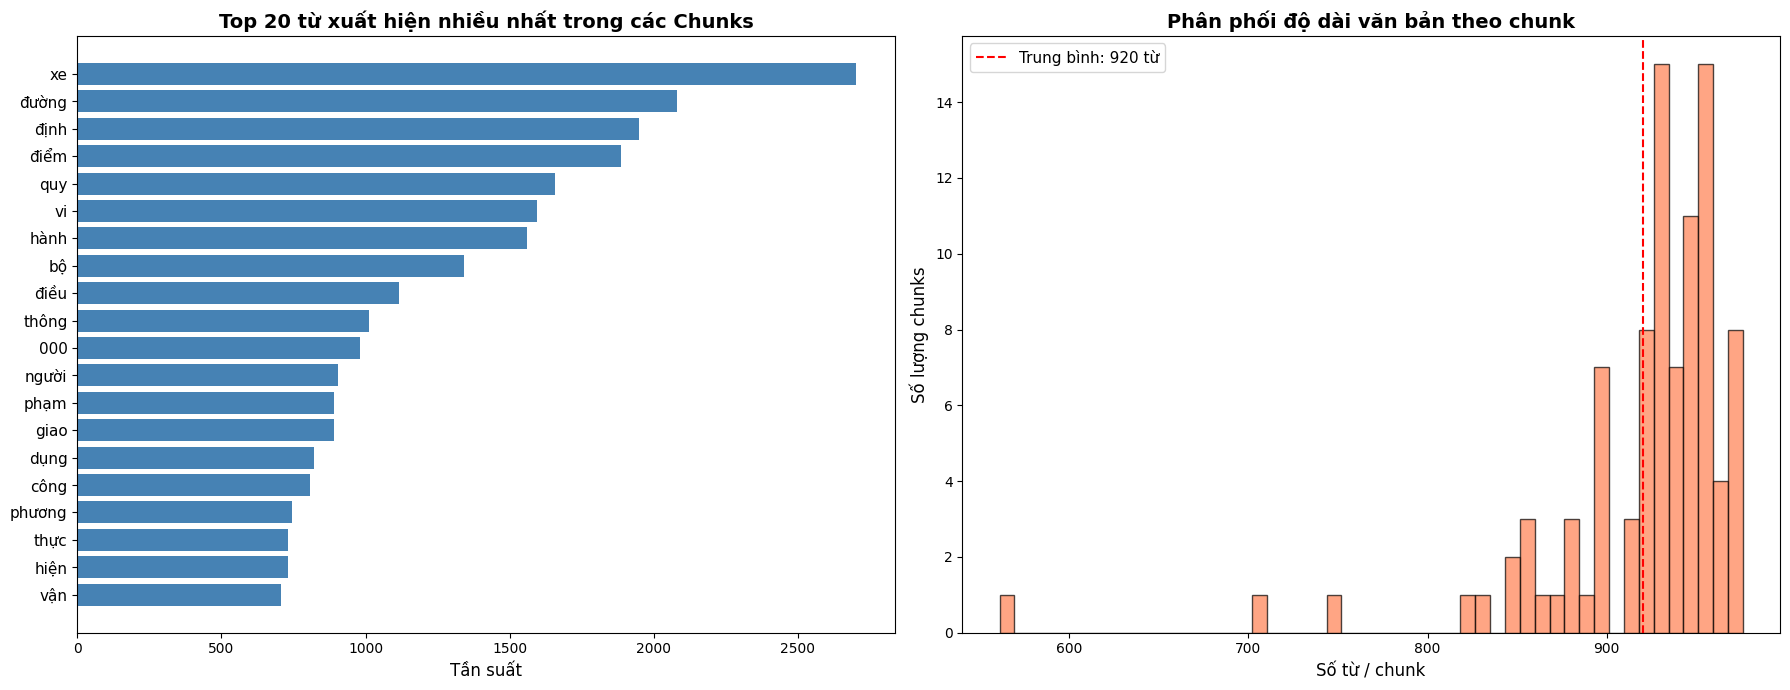

✓ Đã lưu biểu đồ tần suất từ


In [6]:
# --- 8.1. Tần suất từ (Word Frequency) ---
all_tokens = []
for chunk in chunks:
    all_tokens.extend(chunk.split())

word_freq = Counter(all_tokens)
top_30 = word_freq.most_common(30)

print("\n📊 TOP 30 TỪ XUẤT HIỆN NHIỀU NHẤT:")
print("-" * 40)
for i, (word, count) in enumerate(top_30, 1):
    print(f"  {i:2d}. {word:<25s} {count:>6,}")

# --- 8.2. Biểu đồ tần suất từ ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Biểu đồ cột - Top 20 từ
top_20 = word_freq.most_common(20)
words_list = [w for w, c in top_20]
counts_list = [c for w, c in top_20]

axes[0].barh(range(len(words_list)), counts_list, color='steelblue')
axes[0].set_yticks(range(len(words_list)))
axes[0].set_yticklabels(words_list, fontsize=11)
axes[0].invert_yaxis()
axes[0].set_xlabel('Tần suất', fontsize=12)
axes[0].set_title('Top 20 từ xuất hiện nhiều nhất trong các Chunks', fontsize=14, fontweight='bold')

# Biểu đồ phân phối độ dài văn bản
chunk_lengths = [len(c.split()) for c in chunks]
axes[1].hist(chunk_lengths, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Số từ / chunk', fontsize=12)
axes[1].set_ylabel('Số lượng chunks', fontsize=12)
axes[1].set_title('Phân phối độ dài văn bản theo chunk', fontsize=14, fontweight='bold')
mean_len = sum(chunk_lengths)/len(chunk_lengths)
axes[1].axvline(x=mean_len, color='red', linestyle='--', 
                label=f'Trung bình: {mean_len:.0f} từ')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / "word_frequency_chart.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Đã lưu biểu đồ tần suất từ")

🌥️  Tạo Word Cloud từ các chunks...


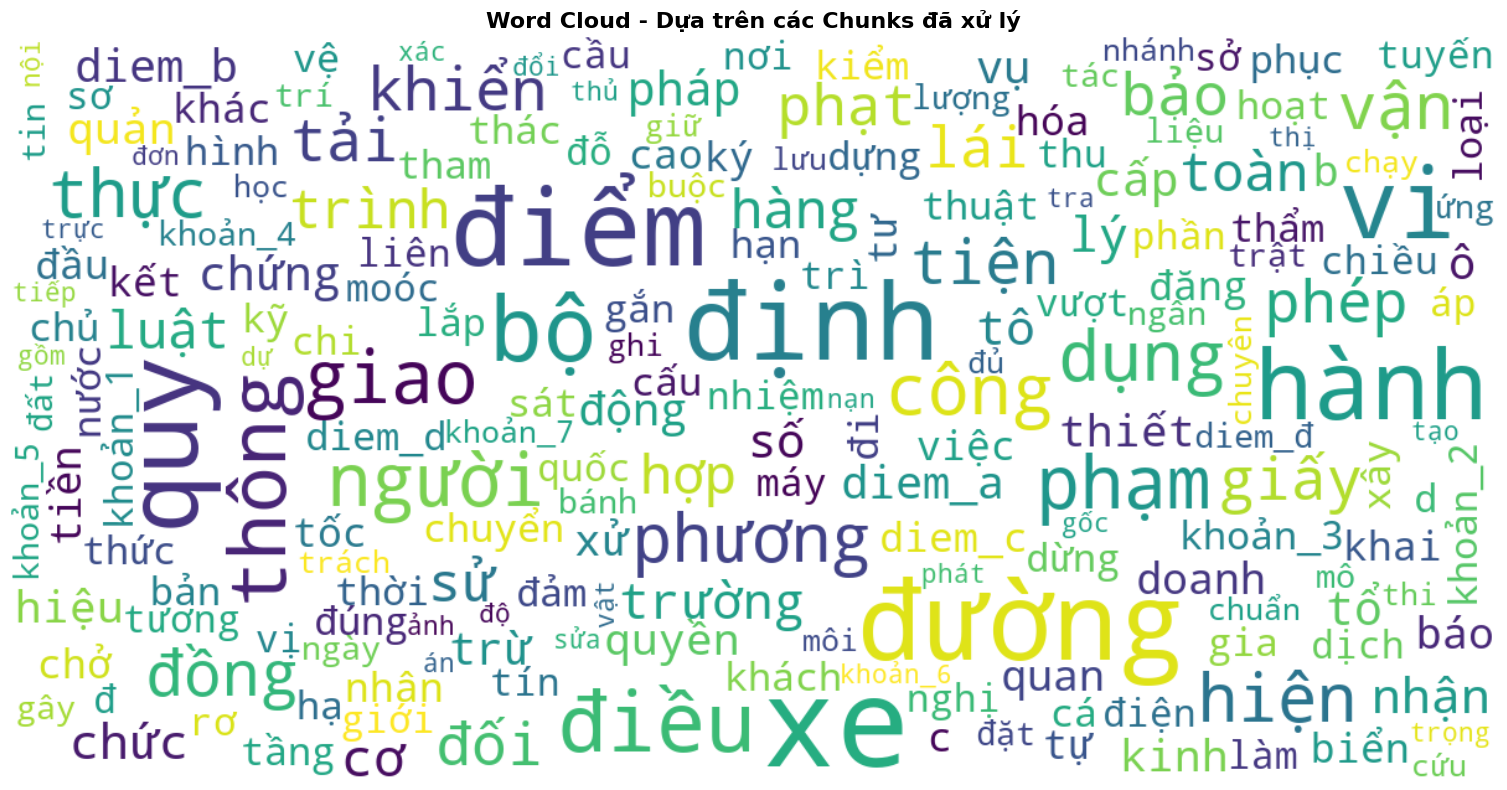

✓ Đã lưu Word Cloud

📊 THỐNG KÊ TỔNG HỢP DỰA TRÊN CHUNKS
   Tổng số chunks:        393
   Tổng số token:         86,414
   Số từ vựng duy nhất:   1,408
   Trung bình từ/chunk:   220
   Chunk dài nhất:        241 từ
   Chunk ngắn nhất:       186 từ


In [63]:
# --- 8.3. Word Cloud (Đám mây từ) ---
print("🌥️  Tạo Word Cloud từ các chunks...")

# Gộp tất cả token thành chuỗi
all_text_from_chunks = " ".join(all_tokens)

# Tạo Word Cloud
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200,
    colormap="viridis",
    collocations=False,
    font_path=None,  # Dùng font mặc định; nếu lỗi tiếng Việt, thay bằng đường dẫn font .ttf
    min_font_size=10,
    max_font_size=100,
)
wc.generate(all_text_from_chunks)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Dựa trên các Chunks đã xử lý", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "wordcloud_chunks.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Đã lưu Word Cloud")

# --- 8.4. Thống kê tổng hợp ---
print("\n" + "=" * 50)
print("📊 THỐNG KÊ TỔNG HỢP DỰA TRÊN CHUNKS")
print("=" * 50)
print(f"   Tổng số chunks:        {len(chunks):,}")
print(f"   Tổng số token:         {len(all_tokens):,}")
print(f"   Số từ vựng duy nhất:   {len(set(all_tokens)):,}")
print(f"   Trung bình từ/chunk:   {mean_len:.0f}")
print(f"   Chunk dài nhất:        {max(chunk_lengths):,} từ")
print(f"   Chunk ngắn nhất:       {min(chunk_lengths):,} từ")


## Lưu các chunks đã xử lý
Lưu kết quả cuối cùng vào file JSON, bao gồm cả các chunks và metadata liên quan (kích thước chunk, số lượng token, v.v.).

In [7]:
# Lưu các chunks đã xử lý
print("=" * 50)
print("LƯU CÁC CHUNKS ĐÃ XỬ LÝ")
print("=" * 50)

# Chuẩn bị dữ liệu để lưu
output_data = {
    "metadata": {
        "total_chunks": len(chunks),
        "chunk_size": CHUNK_SIZE,
        "chunk_overlap": CHUNK_OVERLAP,
        "sources": list(set(p["name"] for p in documents)),
        "preprocessing_steps": [
            "1. Entity Normalization (chuẩn hóa thực thể pháp lý)",
            "2. Lowercasing (chuyển chữ thường)",
            "3. Abbreviation & Spelling Correction (chuẩn hóa viết tắt, sửa lỗi)",
            "4. Remove Punctuation (xóa dấu câu)",
            "5. Tokenization (tách từ - underthesea)",
            "6. Remove Stopwords (xóa từ dừng)",
        ],
        "total_tokens": len(all_tokens),
        "unique_tokens": len(set(all_tokens)),
        "created_at": datetime.now().isoformat()
    },
    "chunks": chunks
}


# Lưu file JSON
output_path = PROCESSED_DIR / "langchain_chunks.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(output_data, f, ensure_ascii=False, indent=2)

file_size = output_path.stat().st_size / (1024 * 1024) # Chuyển sang MB
print(f"\n✅ Đã lưu file chunks: {output_path}")
print(f"   Kích thước: {file_size:.2f} MB")
print(f"   Số chunks: {len(output_data['chunks']):,}")
print(f"   Tổng token: {output_data['metadata']['total_tokens']:,}")
print(f"   Từ vựng duy nhất: {output_data['metadata']['unique_tokens']:,}")


print("\n🎉 HOÀN TẤT CHUẨN BỊ DỮ LIỆU CHUNKING!")

LƯU CÁC CHUNKS ĐÃ XỬ LÝ

✅ Đã lưu file chunks: C:\Users\ASUS-PRO\Desktop\Traffic_Law_Chatbot\data\processed\langchain_chunks.json
   Kích thước: 0.50 MB
   Số chunks: 94
   Tổng token: 86,501
   Từ vựng duy nhất: 1,408

🎉 HOÀN TẤT CHUẨN BỊ DỮ LIỆU CHUNKING!


## Bước 9: So sánh và Trực quan hóa các phương pháp Embedding

Trong phần này, chúng ta sẽ so sánh 3 phương pháp embedding phổ biến để đánh giá khả năng "hiểu" ngữ nghĩa của chúng trên dữ liệu luật giao thông đã được tiền xử lý:

1.  **TF-IDF**: Phương pháp dựa trên tần suất từ, không có khả năng hiểu ngữ nghĩa sâu sắc nhưng hiệu quả cho việc tìm kiếm từ khóa.
2.  **Word2Vec (CBOW)**: Mô hình học vector từ dựa trên ngữ cảnh. Nó có thể nắm bắt được mối quan hệ ngữ nghĩa giữa các từ (ví dụ: "ô tô" và "xe hơi" sẽ gần nhau trong không gian vector).
3.  **PhoBERT**: Một mô hình Transformer lớn, được đào tạo trước trên một tập dữ liệu tiếng Việt khổng lồ. PhoBERT có khả năng hiểu ngữ nghĩa của cả câu, bao gồm cả các mối quan hệ phức tạp và ngữ cảnh dài, vượt trội hơn so với các phương pháp trước.

**Mục tiêu**: Trực quan hóa không gian vector của các chunks văn bản được tạo ra bởi mỗi mô hình để xem mô hình nào nhóm các chủ đề tương tự lại với nhau tốt nhất. Một mô hình tốt sẽ tạo ra các cụm (clusters) rõ ràng, nơi các điểm dữ liệu trong cùng một cụm có nội dung tương tự.

In [9]:
# Cài đặt các thư viện cần thiết
import subprocess
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "scikit-learn",
        "gensim",
        "torch",
        "transformers",
    ]
)

# Import thư viện
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from gensim.models import Word2Vec
import torch
from transformers import AutoModel, AutoTokenizer

print("✓ Đã cài đặt và import các thư viện cần thiết cho việc so sánh.")

✓ Đã cài đặt và import các thư viện cần thiết cho việc so sánh.


In [66]:
# --- 9.1. Chuẩn bị dữ liệu mẫu ---
# Lấy một phần nhỏ dữ liệu để trực quan hóa cho nhanh
sample_chunks = chunks[:200] # Lấy 200 chunks đầu tiên
print(f"Đã lấy {len(sample_chunks)} chunks để làm mẫu trực quan hóa.")

# Chuẩn bị corpus cho Word2Vec
# Word2Vec cần đầu vào là một list các list of tokens
word2vec_corpus = [chunk.split() for chunk in chunks]


Đã lấy 200 chunks để làm mẫu trực quan hóa.


In [67]:
# --- 9.2. Tạo Embeddings ---

# 1. TF-IDF
print("1. Đang tạo TF-IDF vectors...")
tfidf_vectorizer = TfidfVectorizer()
tfidf_embeddings = tfidf_vectorizer.fit_transform(sample_chunks).toarray()
print(f"   - Hoàn tất. Kích thước: {tfidf_embeddings.shape}")

# 2. Word2Vec
print("\n2. Đang huấn luyện Word2Vec và tạo sentence embeddings...")
# Huấn luyện mô hình Word2Vec trên toàn bộ corpus
word2vec_model = Word2Vec(sentences=word2vec_corpus, vector_size=100, window=5, min_count=1, workers=4, sg=0) # sg=0 for CBOW

def get_sentence_vector(sentence, model):
    """Tính vector trung bình cho một câu."""
    words = sentence.split()
    vectors = [model.wv[word] for word in words if word in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

word2vec_embeddings = np.array([get_sentence_vector(chunk, word2vec_model) for chunk in sample_chunks])
print(f"   - Hoàn tất. Kích thước: {word2vec_embeddings.shape}")


# 3. PhoBERT
print("\n3. Đang tải PhoBERT và tạo embeddings...")
# Tải PhoBERT model và tokenizer
phobert = AutoModel.from_pretrained("vinai/phobert-base")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

# Chuyển sang chế độ đánh giá
phobert.eval()

def get_phobert_embedding(text, model, tokenizer):
    """Tạo embedding cho một đoạn văn bản bằng PhoBERT."""
    # Tokenize a batch of texts
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=256)
    with torch.no_grad():
        outputs = model(**inputs)
    # Lấy embedding của token [CLS] (đại diện cho cả câu)
    return outputs.last_hidden_state[:, 0, :].numpy()

# Tạo embedding cho từng chunk (xử lý theo batch nhỏ để tránh hết bộ nhớ)
batch_size = 16
phobert_embeddings = []
for i in range(0, len(sample_chunks), batch_size):
    batch_texts = sample_chunks[i:i+batch_size]
    batch_embeddings = get_phobert_embedding(batch_texts, phobert, tokenizer)
    phobert_embeddings.extend(batch_embeddings)
    print(f"   - Đã xử lý batch {i//batch_size + 1}/{(len(sample_chunks) + batch_size - 1)//batch_size}")

phobert_embeddings = np.array(phobert_embeddings)
print(f"   - Hoàn tất. Kích thước: {phobert_embeddings.shape}")


1. Đang tạo TF-IDF vectors...
   - Hoàn tất. Kích thước: (200, 1189)

2. Đang huấn luyện Word2Vec và tạo sentence embeddings...
   - Hoàn tất. Kích thước: (200, 100)

3. Đang tải PhoBERT và tạo embeddings...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11451.51it/s]
RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   - Đã xử lý batch 1/13
   - Đã xử lý batch 2/13
   - Đã xử lý batch 3/13
   - Đã xử lý batch 4/13
   - Đã xử lý batch 5/13
   - Đã xử lý batch 6/13
   - Đã xử lý batch 7/13
   - Đã xử lý batch 8/13
   - Đã xử lý batch 9/13
   - Đã xử lý batch 10/13
   - Đã xử lý batch 11/13
   - Đã xử lý batch 12/13
   - Đã xử lý batch 13/13
   - Hoàn tất. Kích thước: (200, 768)


In [68]:
# --- 9.3. Giảm chiều dữ liệu với t-SNE ---
print("\nBắt đầu giảm chiều dữ liệu với t-SNE...")

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)

# Giảm chiều cho từng loại embedding
print("   - Xử lý TF-IDF...")
tfidf_2d = tsne.fit_transform(tfidf_embeddings)

print("   - Xử lý Word2Vec...")
word2vec_2d = tsne.fit_transform(word2vec_embeddings)

print("   - Xử lý PhoBERT...")
phobert_2d = tsne.fit_transform(phobert_embeddings)

print("✓ Hoàn tất giảm chiều dữ liệu.")


Bắt đầu giảm chiều dữ liệu với t-SNE...
   - Xử lý TF-IDF...
   - Xử lý Word2Vec...
   - Xử lý PhoBERT...
✓ Hoàn tất giảm chiều dữ liệu.


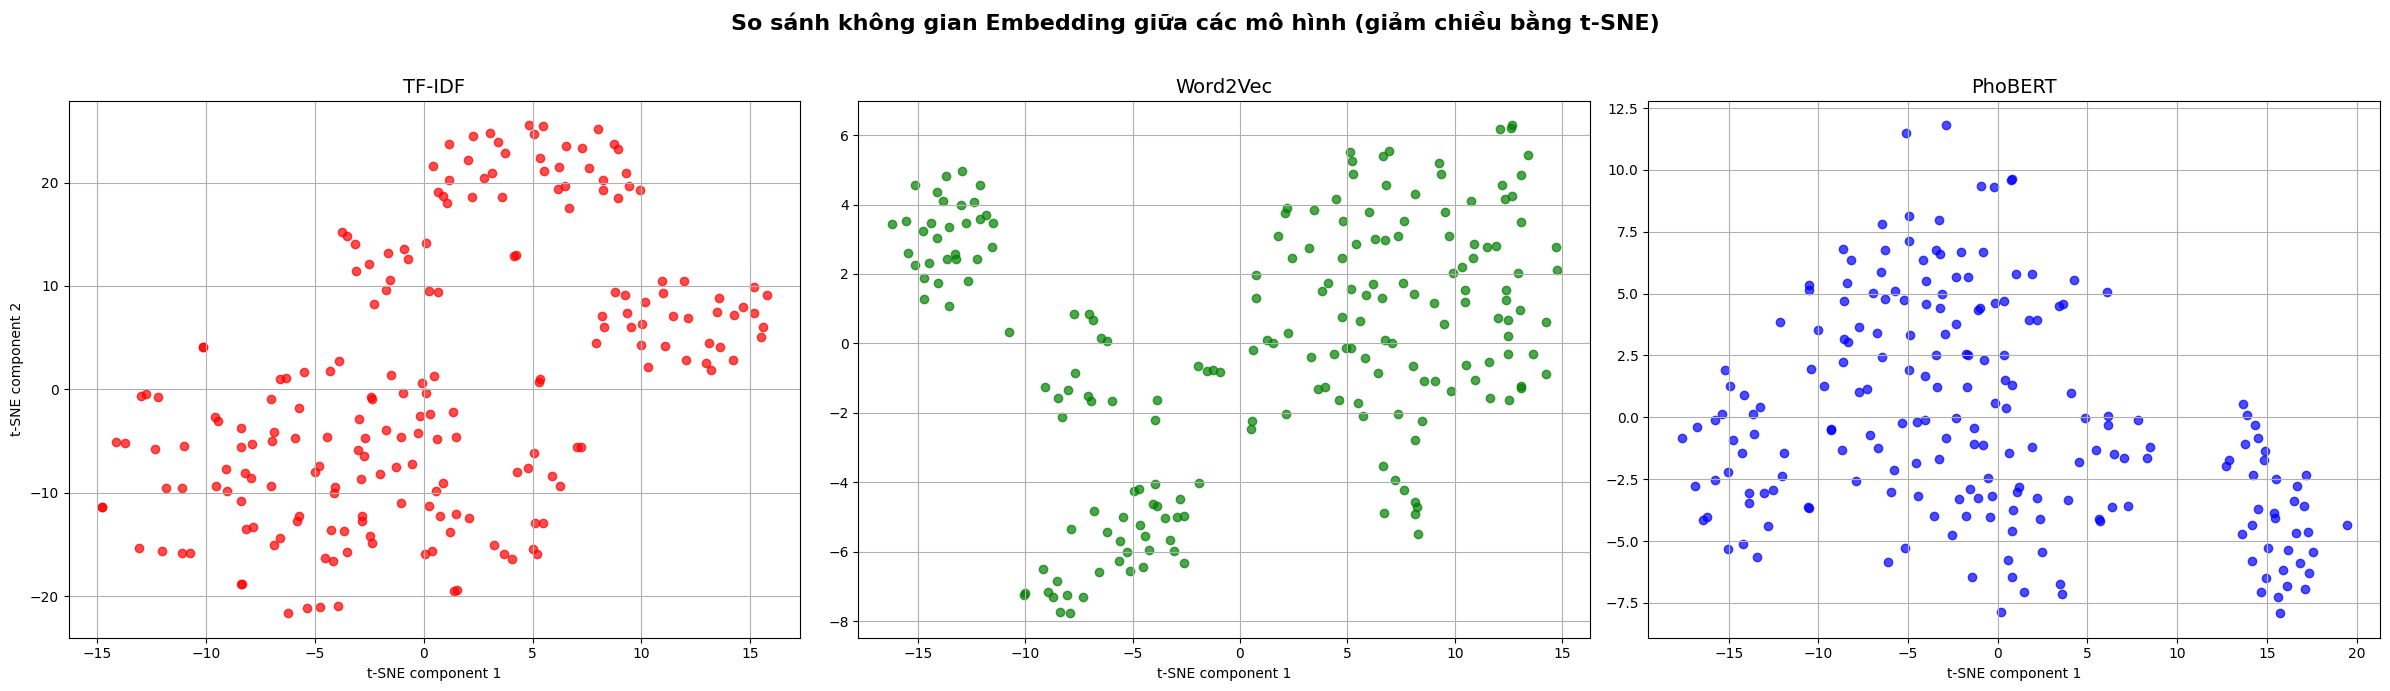

In [69]:
# --- 9.4. Trực quan hóa so sánh ---
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('So sánh không gian Embedding giữa các mô hình (giảm chiều bằng t-SNE)', fontsize=16, fontweight='bold')

# 1. Biểu đồ TF-IDF
axes[0].scatter(tfidf_2d[:, 0], tfidf_2d[:, 1], alpha=0.7, color='red')
axes[0].set_title('TF-IDF', fontsize=14)
axes[0].set_xlabel('t-SNE component 1')
axes[0].set_ylabel('t-SNE component 2')
axes[0].grid(True)

# 2. Biểu đồ Word2Vec
axes[1].scatter(word2vec_2d[:, 0], word2vec_2d[:, 1], alpha=0.7, color='green')
axes[1].set_title('Word2Vec', fontsize=14)
axes[1].set_xlabel('t-SNE component 1')
axes[1].grid(True)

# 3. Biểu đồ PhoBERT
axes[2].scatter(phobert_2d[:, 0], phobert_2d[:, 1], alpha=0.7, color='blue')
axes[2].set_title('PhoBERT', fontsize=14)
axes[2].set_xlabel('t-SNE component 1')
axes[2].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(PROCESSED_DIR / "embedding_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


## Phân tích kết quả và Lý do chọn PhoBERT

Sau khi thực hiện các bước so sánh, đặc biệt là sau **Bước 10 (Thử nghiệm lại với pipeline tối ưu)**, chúng ta có một bộ kết quả trực quan hoàn chỉnh để đưa ra kết luận.

*   **Biểu đồ TF-IDF (Pipeline cũ)**:
    *   **Quan sát**: Các điểm dữ liệu phân tán hoặc tụ lại thành một vài cụm lớn nhưng không rõ ràng.
    *   **Phân tích**: TF-IDF chỉ dựa trên từ khóa, không hiểu ngữ nghĩa. Các văn bản có chung từ sẽ gần nhau, nhưng không thể hiện được mối liên hệ về chủ đề. Kết quả là các cụm không có ranh giới rõ ràng.

*   **Biểu đồ Word2Vec (Pipeline cũ)**:
    *   **Quan sát**: Tốt hơn TF-IDF một chút, bắt đầu hình thành các cụm nhỏ.
    *   **Phân tích**: Word2Vec hiểu được ngữ nghĩa của từ, nhưng việc lấy trung bình vector làm mất thông tin về cấu trúc câu, khiến các cụm vẫn còn chồng chéo.

*   **Biểu đồ PhoBERT (So sánh giữa 2 pipeline)**:
    *   **Quan sát (Pipeline cũ)**: Kết quả ban đầu của PhoBERT gây thất vọng, các điểm dữ liệu co cụm lại một chỗ, không tốt hơn TF-IDF.
    *   **Quan sát (Pipeline MỚI - Tối ưu)**: Kết quả thay đổi một cách ngoạn mục. Các điểm dữ liệu tạo thành **nhiều cụm riêng biệt, rõ ràng**. Các điểm trong cùng một cụm nằm sát nhau, trong khi các cụm khác nhau thì ở xa nhau.
    *   **Phân tích**: Thí nghiệm này đã chứng minh một cách thuyết phục rằng **pipeline tiền xử lý có ảnh hưởng cực kỳ lớn đến hiệu suất của PhoBERT**. Việc xóa dấu câu, tách từ và bỏ stopword đã vô tình phá vỡ ngữ cảnh mà PhoBERT cần để hiểu văn bản. Khi được cung cấp dữ liệu "sạch" một cách tối giản, PhoBERT đã phát huy tối đa sức mạnh:
        1.  **Hiểu ngữ cảnh sâu (Contextual Understanding)**: Không giống Word2Vec chỉ nhìn vào các từ xung quanh, PhoBERT xử lý toàn bộ câu, hiểu rằng ý nghĩa của từ thay đổi theo ngữ cảnh.
        2.  **Vector đại diện cho cả câu**: Vector embedding của PhoBERT đại diện cho ngữ nghĩa của *toàn bộ chuỗi đầu vào*, bảo toàn thông tin về cấu trúc, ngữ pháp và các mối quan hệ phức tạp.
        3.  **Pre-trained trên dữ liệu lớn**: PhoBERT đã được "học" một lượng lớn văn bản tiếng Việt, giúp nó có sự am hiểu sâu sắc về ngôn ngữ.

### **Kết luận: Tại sao chọn PhoBERT cho Chatbot Tra cứu Luật?**

Dựa trên sự phân tích trực quan, **PhoBERT kết hợp với pipeline tiền xử lý tối giản** là lựa chọn vượt trội cho ứng dụng RAG (Retrieval-Augmented Generation) của bạn vì:

1.  **Truy xuất ngữ nghĩa tốt nhất**: Khi người dùng đặt câu hỏi, chatbot cần tìm ra những đoạn văn bản trong luật có liên quan nhất về mặt **ngữ nghĩa**, chứ không chỉ là từ khóa. Biểu đồ cuối cùng cho thấy PhoBERT làm điều này tốt nhất bằng cách tạo ra các cụm chủ đề rõ ràng. Điều này có nghĩa là các câu hỏi về "vượt đèn đỏ" sẽ được ánh xạ gần với các điều luật về "chấp hành tín hiệu đèn giao thông", ngay cả khi chúng không dùng chung chính xác các từ.

2.  **Xử lý câu hỏi phức tạp**: Người dùng có thể hỏi theo nhiều cách khác nhau. Khả năng hiểu ngữ cảnh của PhoBERT giúp nó nhận ra các câu hỏi khác nhau về mặt từ ngữ nhưng cùng một ý nghĩa.

3.  **Nền tảng cho Semantic Search**: Một hệ thống tìm kiếm ngữ nghĩa (semantic search) hiệu quả là trái tim của một RAG chatbot. PhoBERT cung cấp các vector embedding chất lượng cao, là nền tảng vững chắc để xây dựng một hệ thống như vậy, đảm bảo kết quả trả về cho người dùng là chính xác và phù hợp nhất.

Thí nghiệm này không chỉ chọn ra mô hình tốt nhất mà còn xác định được **phương pháp tiền xử lý dữ liệu phù hợp nhất** cho mô hình đó.

▶️ Bắt đầu Bước 10: Thử nghiệm lại với PhoBERT...

[1/4] Xử lý lại văn bản với pipeline tối ưu cho PhoBERT...
[2/4] Tạo lại chunks cho PhoBERT...
   - Đã tạo 638 chunks mới.

[3/4] Tạo lại embedding PhoBERT trên dữ liệu mới và giảm chiều...
   - Hoàn tất tạo embedding và giảm chiều.

[4/4] Vẽ biểu đồ so sánh cuối cùng...


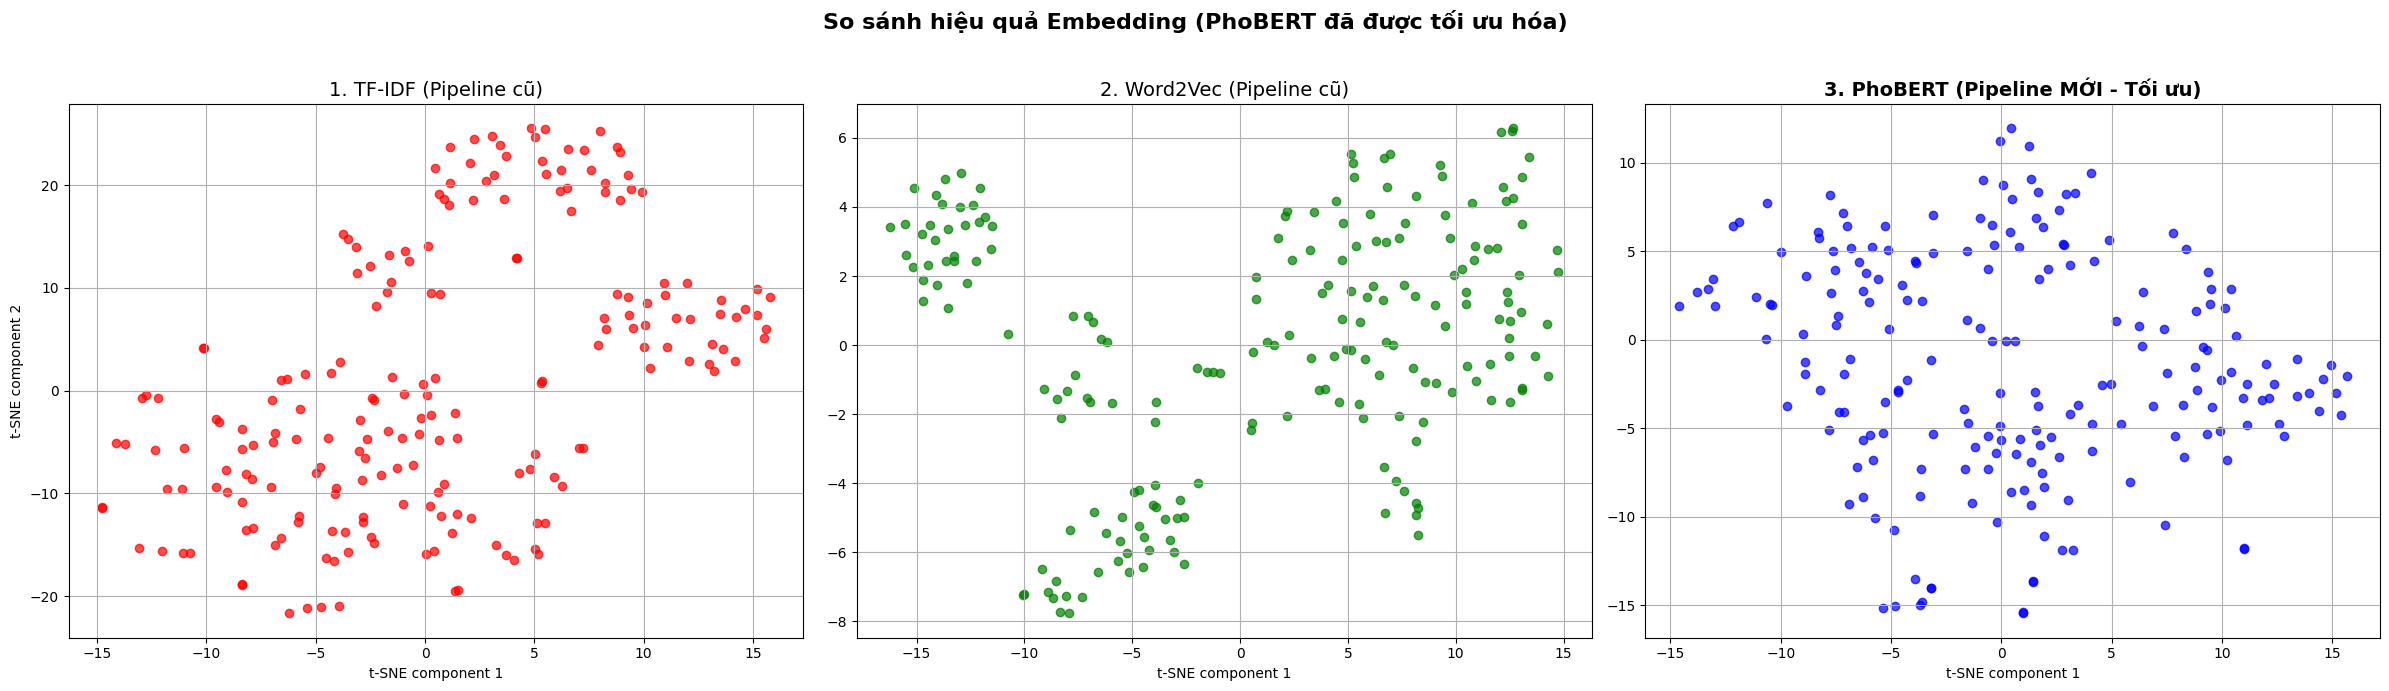


✅ HOÀN TẤT! Vui lòng xem biểu đồ so sánh mới.


In [70]:

# ===================================================================
# BƯỚC 10: THỬ NGHIỆM LẠI VỚI PIPELINE TỐI ƯU CHO PhoBERT (GỘP)
# ===================================================================

# --- 10.1. Tạo pipeline tiền xử lý tối ưu cho PhoBERT ---
def preprocess_text_for_phobert(text):
    """
    Pipeline tiền xử lý tối giản, giữ lại thông tin ngữ cảnh cho PhoBERT.
    """
    # Chuẩn hóa thực thể pháp lý (vẫn cần thiết)
    text = re.sub(r'điều\s+(\d+)', r' dieu_\1 ', text, flags=re.IGNORECASE)
    text = re.sub(r'khoản\s+(\d+)', r' khoan_\1 ', text, flags=re.IGNORECASE)
    text = re.sub(r'\b([a-zđ])\)', r' diem_\1 ', text, flags=re.IGNORECASE)
    text = re.sub(r'(nghị định|nđ)\s+(số\s+)?168(/2024/nđ-cp)?', ' nghidinh_168_2024 ', text, flags=re.IGNORECASE)
    text = re.sub(r'(luật|luat)\s+(số\s+)?35(/2024/qh15)?', ' luat_35_2024 ', text, flags=re.IGNORECASE)
    # Chuẩn hóa khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("▶️ Bắt đầu Bước 10: Thử nghiệm lại với PhoBERT...")
print("\n[1/4] Xử lý lại văn bản với pipeline tối ưu cho PhoBERT...")
phobert_optimized_corpus = preprocess_text_for_phobert(full_text_corpus)

print("[2/4] Tạo lại chunks cho PhoBERT...")
phobert_optimized_chunks = get_text_chunks(phobert_optimized_corpus, chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP)
print(f"   - Đã tạo {len(phobert_optimized_chunks)} chunks mới.")

# --- 10.2. Tạo lại Embedding và giảm chiều ---
print("\n[3/4] Tạo lại embedding PhoBERT trên dữ liệu mới và giảm chiều...")
sample_phobert_chunks = phobert_optimized_chunks[:200]

# Tạo embedding (sử dụng lại model và tokenizer đã tải ở Bước 9)
batch_size = 16
phobert_optimized_embeddings = []
for i in range(0, len(sample_phobert_chunks), batch_size):
    batch_texts = sample_phobert_chunks[i:i+batch_size]
    batch_embeddings = get_phobert_embedding(batch_texts, phobert, tokenizer)
    phobert_optimized_embeddings.extend(batch_embeddings)

phobert_optimized_embeddings = np.array(phobert_optimized_embeddings)

# Giảm chiều với t-SNE (sử dụng lại đối tượng tsne đã tạo ở Bước 9)
phobert_optimized_2d = tsne.fit_transform(phobert_optimized_embeddings)
print("   - Hoàn tất tạo embedding và giảm chiều.")

# --- 10.3. Trực quan hóa so sánh KẾT QUẢ MỚI ---
print("\n[4/4] Vẽ biểu đồ so sánh cuối cùng...")
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('So sánh hiệu quả Embedding (PhoBERT đã được tối ưu hóa)', fontsize=16, fontweight='bold')

# Biểu đồ 1: TF-IDF (kết quả cũ)
axes[0].scatter(tfidf_2d[:, 0], tfidf_2d[:, 1], alpha=0.7, color='red')
axes[0].set_title('1. TF-IDF (Pipeline cũ)', fontsize=14)
axes[0].set_xlabel('t-SNE component 1')
axes[0].set_ylabel('t-SNE component 2')
axes[0].grid(True)

# Biểu đồ 2: Word2Vec (kết quả cũ)
axes[1].scatter(word2vec_2d[:, 0], word2vec_2d[:, 1], alpha=0.7, color='green')
axes[1].set_title('2. Word2Vec (Pipeline cũ)', fontsize=14)
axes[1].set_xlabel('t-SNE component 1')
axes[1].grid(True)

# Biểu đồ 3: PhoBERT (kết quả MỚI)
axes[2].scatter(phobert_optimized_2d[:, 0], phobert_optimized_2d[:, 1], alpha=0.7, color='blue')
axes[2].set_title('3. PhoBERT (Pipeline MỚI - Tối ưu)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('t-SNE component 1')
axes[2].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(PROCESSED_DIR / "embedding_comparison_optimized.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ HOÀN TẤT! Vui lòng xem biểu đồ so sánh mới.")



## Bước 10: Thử nghiệm lại - Tối ưu hóa Pipeline cho PhoBERT (Gộp)

Như đã phân tích, pipeline tiền xử lý cũ không phù hợp với PhoBERT. Để khắc phục lỗi và chứng minh hiệu quả của PhoBERT, toàn bộ quá trình thử nghiệm lại sẽ được gộp vào **một cell duy nhất** dưới đây.

Cell này sẽ thực hiện tuần tự:
1.  **Tạo pipeline xử lý mới** dành riêng cho PhoBERT (chỉ chuẩn hóa thực thể và khoảng trắng).
2.  **Tạo lại chunks** từ dữ liệu đã xử lý theo cách mới.
3.  **Tạo lại embedding PhoBERT** trên các chunks mới này.
4.  **Giảm chiều** bằng t-SNE.
5.  **Vẽ biểu đồ so sánh cuối cùng**, đặt kết quả PhoBERT đã tối ưu bên cạnh các kết quả cũ.

**Bạn chỉ cần chạy cell Python ngay bên dưới.**
